In [8]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [19]:
%%R
install.packages("pwr")
library(dplyr)
library(readr)
library(lubridate)

library(pwr)


if (!require(caret)) {
    install.packages("caret")
    library(caret)
}
if (!require(glmnet)) {
    install.packages("glmnet")
    library(glmnet)
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/pwr_1.3-0.tar.gz'
Content type 'application/x-gzip' length 80426 bytes (78 KB)
downloaded 78 KB


The downloaded source packages are in
	‘/tmp/RtmpRf9157/downloaded_packages’


In [10]:
%%R
data <- read.csv("Wdata.csv", stringsAsFactors = FALSE)

names(data)[names(data) == "Rel.Hum."] <- "Rel_Hum"

data$Date.Time <- parse_date_time(data$Date.Time, orders = "mdy HM")

print(paste("Размер:", nrow(data)))
print(paste("NA в датах:", sum(is.na(data$Date.Time))))
str(data)
head(data)


[1] "Размер: 8784"
[1] "NA в датах: 0"
'data.frame':	8784 obs. of  8 variables:
 $ Date.Time       : POSIXct, format: "2012-01-01 00:00:00" "2012-01-01 01:00:00" ...
 $ Temp_C          : num  -1.8 -1.8 -1.8 -1.5 -1.5 -1.4 -1.5 -1.4 -1.4 -1.3 ...
 $ Dew.Point.Temp_C: num  -3.9 -3.7 -3.4 -3.2 -3.3 -3.3 -3.1 -3.6 -3.6 -3.1 ...
 $ Rel.Hum_.       : int  86 87 89 88 88 87 89 85 85 88 ...
 $ Wind.Speed_km.h : int  4 4 7 6 7 9 7 7 9 15 ...
 $ Visibility_km   : num  8 8 4 4 4.8 6.4 6.4 8 8 4 ...
 $ Press_kPa       : num  101 101 101 101 101 ...
 $ Weather         : chr  "Fog" "Fog" "Freezing Drizzle,Fog" "Freezing Drizzle,Fog" ...
            Date.Time Temp_C Dew.Point.Temp_C Rel.Hum_. Wind.Speed_km.h
1 2012-01-01 00:00:00   -1.8             -3.9        86               4
2 2012-01-01 01:00:00   -1.8             -3.7        87               4
3 2012-01-01 02:00:00   -1.8             -3.4        89               7
4 2012-01-01 03:00:00   -1.5             -3.2        88               6
5 2012-01

In [11]:
%%R
alpha <- c(0.01, 0.05, 0.1)
SData1 <- rnorm(1000, mean = 1, sd = sqrt(10))
SData2 <- rnorm(1000, mean = 3, sd = sqrt(10))

# Часть 1

In [12]:
%%R
if (!require(pwr)) {
    install.packages("pwr")
    library(pwr)
}

t_test_two <- t.test(SData1, SData2, var.equal = FALSE)
t_test_g <- t.test(SData1, SData2, alternative = "greater")
t_test_l <- t.test(SData1, SData2, alternative = "less")

print(paste('P-Значения:'))
print(paste('Двусторонний:', t_test_two$p.value))
print(paste('Правосторонний:', t_test_g$p.value))
print(paste('Левосторонний:', t_test_l$p.value))
print(paste('По уровням значимости:'))

n1 <- length(SData1)
n2 <- length(SData2)
print(n1)
print(n2)

effect_size <- (mean(SData1) - mean(SData2)) / sqrt(((n1-1)*var(SData1) + (n2-1)*var(SData2))/(n1+n2-2))
ratio <- n2/n1


pooled_sd <- sqrt(((n1-1)*var(SData1) + (n2-1)*var(SData2))/(n1+n2-2))
cohens_d <- abs(mean(SData1) - mean(SData2)) / pooled_sd

print(paste("Cohen's d:", cohens_d))


for (a in alpha) {
  print(paste("  Alpha =", a))


  power_result <- pwr.t.test(n = n1, d = cohens_d, sig.level = a, type = "two.sample", alternative = "two.sided")
  power_two_sided <- power_result$power

  power_result_greater <- pwr.t.test(n = n1, d = cohens_d, sig.level = a, type = "two.sample", alternative = "greater")
  power_greater <- power_result_greater$power

  power_result_less <- pwr.t.test(n = n1, d = cohens_d, sig.level = a, type = "two.sample", alternative = "less")
  power_less <- power_result_less$power

  print(paste("Мощность двустороннего критерия:", round(power_two_sided, 3)))
  print(paste("Мощность правостороннего критерия:", round(power_greater, 3)))
  print(paste("Мощность левостороннего критерия:", round(power_less, 3)))

  n_required <- pwr.t.test(d = cohens_d, sig.level = a, power = 0.8, type = "two.sample", alternative = "two.sided")$n
  print(paste("желаемый объем выборок:", ceiling(n_required)))
  print(paste(rep('-', 50), collapse = ''))
}
print(paste("Текущий объем выборки:", n1))

[1] "P-Значения:"
[1] "Двусторонний: 1.62411924525179e-36"
[1] "Правосторонний: 1"
[1] "Левосторонний: 8.12059622625896e-37"
[1] "По уровням значимости:"
[1] 1000
[1] 1000
[1] "Cohen's d: 0.575933282595914"
[1] "  Alpha = 0.01"
[1] "Мощность двустороннего критерия: 1"
[1] "Мощность правостороннего критерия: 1"
[1] "Мощность левостороннего критерия: 0"
[1] "желаемый объем выборок: 73"
[1] "--------------------------------------------------"
[1] "  Alpha = 0.05"
[1] "Мощность двустороннего критерия: 1"
[1] "Мощность правостороннего критерия: 1"
[1] "Мощность левостороннего критерия: 0"
[1] "желаемый объем выборок: 49"
[1] "--------------------------------------------------"
[1] "  Alpha = 0.1"
[1] "Мощность двустороннего критерия: 1"
[1] "Мощность правостороннего критерия: 1"
[1] "Мощность левостороннего критерия: 0"
[1] "желаемый объем выборок: 38"
[1] "--------------------------------------------------"
[1] "Текущий объем выборки: 1000"


In [13]:
 %%R
 # ранговый Критерий Уилкоксона-Манна-Уитни проверяет схожесть распределений, используя порядковые номера элементов
stat_two <- wilcox.test(SData1, SData2, alternative = "two.sided")
stat_greater <- wilcox.test(SData1, SData2, alternative = "greater")
stat_less <- wilcox.test(SData1, SData2, alternative = "less")

print(paste('P-Значения:'))
print(paste('Двусторонний:', stat_two$p.value))
print(paste('Правосторонний:', stat_greater$p.value))
print(paste('Левосторонний:', stat_less$p.value))
print(paste('По уровням значимости:'))

results <- list()
for (a in alpha) {
    alpha1 <- 1 - a
    print(paste("(Alpha =", a, ")"))
    print(paste("Двусторонний: Отвергнуть H₀:", stat_two$p.value < a))
    print(paste("Правосторонний (>): Отвергнуть H₀:", stat_greater$p.value < a))
    print(paste("Левосторонний (<): Отвергнуть H₀:", stat_less$p.value < a))
    print(paste(rep('-', 50), collapse = ''))
}

[1] "P-Значения:"
[1] "Двусторонний: 4.31045700082473e-34"
[1] "Правосторонний: 1"
[1] "Левосторонний: 2.15522850041236e-34"
[1] "По уровням значимости:"
[1] "(Alpha = 0.01 )"
[1] "Двусторонний: Отвергнуть H₀: TRUE"
[1] "Правосторонний (>): Отвергнуть H₀: FALSE"
[1] "Левосторонний (<): Отвергнуть H₀: TRUE"
[1] "--------------------------------------------------"
[1] "(Alpha = 0.05 )"
[1] "Двусторонний: Отвергнуть H₀: TRUE"
[1] "Правосторонний (>): Отвергнуть H₀: FALSE"
[1] "Левосторонний (<): Отвергнуть H₀: TRUE"
[1] "--------------------------------------------------"
[1] "(Alpha = 0.1 )"
[1] "Двусторонний: Отвергнуть H₀: TRUE"
[1] "Правосторонний (>): Отвергнуть H₀: FALSE"
[1] "Левосторонний (<): Отвергнуть H₀: TRUE"
[1] "--------------------------------------------------"


In [23]:
%%R
print("уровни значимости: [0.01, 0.05, 0.1]")

df1 <- length(SData1) - 1
df2 <- length(SData2) - 1
f_stat <- var(SData1) / var(SData2)
p_value <- 2 * min(pf(f_stat, df1, df2), 1 - pf(f_stat, df1, df2))
print("Тест Фишера")
print(paste("p-value=", round(p_value, 3)))
print(paste("Дисперсии равны с опред. уровнем значимости:", alpha < p_value))
print(paste(rep('-', 50), collapse = ''))

# ВМЕСТО car используем lawstat для теста Левена
if (!require(lawstat)) {
    install.packages("lawstat")
    library(lawstat)
}

group_data <- c(SData1, SData2)
group_factor <- factor(rep(c("Group1", "Group2"), c(length(SData1), length(SData2))))

# Используем lawstat::levene.test вместо car::leveneTest
levene_test <- levene.test(group_data, group_factor)
print("Тест Левена")
print(paste("p-value=", round(levene_test$p.value, 3)))
print(paste("Дисперсии равны с опред. уровнем значимости:", alpha < levene_test$p.value))
print(paste(rep('-', 50), collapse = ''))

bartlett_test <- bartlett.test(list(SData1, SData2))
print("Тест Бартлета")
print(paste("p-value=", round(bartlett_test$p.value, 3)))
print(paste("Дисперсии равны с опред. уровнем значимости:", alpha < bartlett_test$p.value))
print(paste(rep('-', 50), collapse = ''))

fligner_test <- fligner.test(list(SData1, SData2))
print("Тест Флингера")
print(paste("p-value=", round(fligner_test$p.value, 3)))
print(paste("Дисперсии равны с опред. уровнем значимости:", alpha < fligner_test$p.value))
print(paste(rep('-', 50), collapse = ''))

[1] "уровни значимости: [0.01, 0.05, 0.1]"
[1] "Тест Фишера"
[1] "p-value= 0.443"
[1] "Дисперсии равны с опред. уровнем значимости: TRUE"
[2] "Дисперсии равны с опред. уровнем значимости: TRUE"
[3] "Дисперсии равны с опред. уровнем значимости: TRUE"
[1] "--------------------------------------------------"
[1] "Тест Левена"
[1] "p-value= 0.331"
[1] "Дисперсии равны с опред. уровнем значимости: TRUE"
[2] "Дисперсии равны с опред. уровнем значимости: TRUE"
[3] "Дисперсии равны с опред. уровнем значимости: TRUE"
[1] "--------------------------------------------------"
[1] "Тест Бартлета"
[1] "p-value= 0.443"
[1] "Дисперсии равны с опред. уровнем значимости: TRUE"
[2] "Дисперсии равны с опред. уровнем значимости: TRUE"
[3] "Дисперсии равны с опред. уровнем значимости: TRUE"
[1] "--------------------------------------------------"
[1] "Тест Флингера"
[1] "p-value= 0.333"
[1] "Дисперсии равны с опред. уровнем значимости: TRUE"
[2] "Дисперсии равны с опред. уровнем значимости: TRUE"
[3] "Диспе

Loading required package: lawstat
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘Kendall’, ‘mvtnorm’

trying URL 'https://cran.rstudio.com/src/contrib/Kendall_2.2.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/mvtnorm_1.3-3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/lawstat_3.6.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpRf9157/downloaded_packages’
In addition: Warning message:
In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘lawstat’


# Пункт 2

In [24]:
%%R
print('Коэффициенты корреляции Пирсона')
print('Требования:')
print('Нормальное распределение всех переменных')
print('Отсутствие сильных выбросов')
print('Корректно интерпретирует только линейные связи')

NData <- data[, !(names(data) %in% c("Weather", "Date.Time"))]

corr_matrix <- cor(NData, method = 'pearson')
print(corr_matrix)

[1] "Коэффициенты корреляции Пирсона"
[1] "Требования:"
[1] "Нормальное распределение всех переменных"
[1] "Отсутствие сильных выбросов"
[1] "Корректно интерпретирует только линейные связи"
                     Temp_C Dew.Point.Temp_C   Rel.Hum_. Wind.Speed_km.h
Temp_C            1.0000000       0.93271415 -0.22018192    -0.061876003
Dew.Point.Temp_C  0.9327141       1.00000000  0.13949383    -0.095685130
Rel.Hum_.        -0.2201819       0.13949383  1.00000000    -0.092743139
Wind.Speed_km.h  -0.0618760      -0.09568513 -0.09274314     1.000000000
Visibility_km     0.2734549       0.05081303 -0.63368318     0.004882697
Press_kPa        -0.2363895      -0.32061553 -0.23142425    -0.356613104
                 Visibility_km  Press_kPa
Temp_C             0.273454900 -0.2363895
Dew.Point.Temp_C   0.050813035 -0.3206155
Rel.Hum_.         -0.633683184 -0.2314242
Wind.Speed_km.h    0.004882697 -0.3566131
Visibility_km      1.000000000  0.2318474
Press_kPa          0.231847379  1.0000000


In [25]:
%%R
print('Коэффициенты корреляции Спирмена')
print('Требования:')
print('корректно работает при монотонной связи в данных')
print('не требует нормальности, отсутствия сильных выбросов и линейности')

corr_matrix <- cor(NData, method = 'spearman')
print(corr_matrix)

[1] "Коэффициенты корреляции Спирмена"
[1] "Требования:"
[1] "корректно работает при монотонной связи в данных"
[1] "не требует нормальности, отсутствия сильных выбросов и линейности"
                      Temp_C Dew.Point.Temp_C  Rel.Hum_. Wind.Speed_km.h
Temp_C            1.00000000       0.92459645 -0.2280645     -0.04826044
Dew.Point.Temp_C  0.92459645       1.00000000  0.1259211     -0.09041270
Rel.Hum_.        -0.22806455       0.12592111  1.0000000     -0.12148551
Wind.Speed_km.h  -0.04826044      -0.09041270 -0.1214855      1.00000000
Visibility_km     0.20061481      -0.01233284 -0.5756434     -0.04165954
Press_kPa        -0.24519489      -0.33614333 -0.2408361     -0.31860708
                 Visibility_km  Press_kPa
Temp_C              0.20061481 -0.2451949
Dew.Point.Temp_C   -0.01233284 -0.3361433
Rel.Hum_.          -0.57564338 -0.2408361
Wind.Speed_km.h    -0.04165954 -0.3186071
Visibility_km       1.00000000  0.2632786
Press_kPa           0.26327860  1.0000000


In [26]:

%%R
print('Коэффициенты корреляции Кендалла')
print('Требования:')
print('корректно работает при монотонной связи в данных')
print('не требует нормальности, отсутствия сильных выбросов и линейности')

corr_matrix <- cor(NData, method = 'kendall')
print(corr_matrix)

[1] "Коэффициенты корреляции Кендалла"
[1] "Требования:"
[1] "корректно работает при монотонной связи в данных"
[1] "не требует нормальности, отсутствия сильных выбросов и линейности"
                      Temp_C Dew.Point.Temp_C   Rel.Hum_. Wind.Speed_km.h
Temp_C            1.00000000      0.767642169 -0.14963828     -0.03131778
Dew.Point.Temp_C  0.76764217      1.000000000  0.08689802     -0.06148099
Rel.Hum_.        -0.14963828      0.086898020  1.00000000     -0.08450032
Wind.Speed_km.h  -0.03131778     -0.061480990 -0.08450032      1.00000000
Visibility_km     0.15031046     -0.008592935 -0.45080386     -0.03170897
Press_kPa        -0.16440704     -0.229040936 -0.16253630     -0.22413553
                 Visibility_km  Press_kPa
Temp_C             0.150310462 -0.1644070
Dew.Point.Temp_C  -0.008592935 -0.2290409
Rel.Hum_.         -0.450803862 -0.1625363
Wind.Speed_km.h   -0.031708974 -0.2241355
Visibility_km      1.000000000  0.1953193
Press_kPa          0.195319262  1.0000000


# Пункт 3

In [27]:
%%R
#исследуем связь Weather ~ Temp_C, строим таблицу сопряженности

my_func <- function(x) {
  if(x > 10) {
    return(2)
  } else if(x > 0) {
    return(1)
  } else if(x > -10) {
    return(-1)
  } else {
    return(-2)
  }
}

MData <- data[, c('Weather', 'Press_kPa', 'Temp_C')]

expanded_rows <- list()
for(i in 1:nrow(MData)) {
  weather_values <- strsplit(MData$Weather[i], ",")[[1]]
  for(j in 1:length(weather_values)) {
    new_row <- MData[i, ]
    new_row$Weather <- trimws(weather_values[j])
    expanded_rows[[length(expanded_rows) + 1]] <- new_row
  }
}

MData <- do.call(rbind, expanded_rows)
MData1 <- MData

ll <- table(MData$Weather)

MData$Temp_C <- sapply(MData$Temp_C, my_func)

MData$Weather <- ifelse(ll[MData$Weather] < 100, "Others", MData$Weather)

columns <- unique(MData$Weather)
index <- c(-1, -2, 1, 2)

varData <- matrix(0, nrow = length(index), ncol = length(columns))
for(i in 1:length(columns)) {
  for(j in 1:length(index)) {
    varData[j, i] <- nrow(MData[MData$Weather == columns[i] & MData$Temp_C == index[j], ])
  }
}

SM <- as.data.frame(varData)
rownames(SM) <- index
colnames(SM) <- columns
print(head(SM))

   Fog Others Mostly Cloudy Cloudy Rain Rain Showers Mainly Clear Snow Clear
-1  67    135           302    326    1            0          296  339   289
-2  15     14            91     89    0            0          120   41   147
1  208     42           558    537  264           73          338  128   302
2  132     30          1118    776  189          137         1352    0   588
   Drizzle
-1       1
-2       0
1       87
2       51


In [29]:
#тест Хи-квадрат проверяет наличие статистически-значимой связи между категориальными переменными
#ни одна частота не должна быть меньше 5 общее число измерений >20
#H0-не зависят
%%R
SM_hi <- SM
chi2_test <- chisq.test(SM_hi)
print(paste("Хи-квадрат: p-value связи между категориями Temp_C и Weather =", chi2_test$p.value, ", статистика =", chi2_test$statistic))

#точный тест Фишера(более точная оценка p-value, таблица 2х2, большие вычисления на больших выборках)
fisher_test <- fisher.test(SM_hi[, c('Cloudy', 'Clear')][c(1,2), ], alternative = "two.sided")
print(paste("Точный тест Фишера: p-value связи между категориями Temp_C и Weather в подтаблице =", fisher_test$p.value))

#тест МакНемара (в отличие от предыдущих тестов репрезентация работает на связанных данных)
#H0 - Вероятность изменения из состояния A в состояние B равна вероятности изменения из состояния B в состояние A
# Правильное создание матрицы для теста МакНемара
mcnemar_matrix <- as.matrix(SM_hi[, c('Cloudy', 'Clear')][c(1,2), ])
mcnemar_test <- mcnemar.test(mcnemar_matrix)
print(paste("Точный тест МакНемара: p-value связи между категориями Temp_C и Weather в подтаблице =", mcnemar_test$p.value))

print("Таким образом, данные зависимы в данных категориях")

[1] "Хи-квадрат: p-value связи между категориями Temp_C и Weather = 0 , статистика = 2046.94015608944"
[1] "Точный тест Фишера: p-value связи между категориями Temp_C и Weather в подтаблице = 6.67404712915556e-05"
[1] "Точный тест МакНемара: p-value связи между категориями Temp_C и Weather в подтаблице = 1.37546317972736e-24"
[1] "Таким образом, данные зависимы в данных категориях"


# Пункт 4

In [30]:
#требование для нахождения фактора инфляции дисперсии: Ни одна переменная не должна быть линейной комбинацией других, Количество наблюдений должно превышать количество признаков
%%R
X_matrix <- as.matrix(NData)

calculate_vif <- function(data_matrix, column_index) {
  y <- data_matrix[, column_index]
  X <- data_matrix[, -column_index]

  X_with_const <- cbind(1, X)

  model <- lm(y ~ X)
  r_squared <- summary(model)$r.squared

  vif <- 1 / (1 - r_squared)
  return(vif)
}

for(i in 1:ncol(NData)) {
  vif_value <- calculate_vif(X_matrix, i)
  print(paste("Для столбца", names(NData)[i], "VIF равен", round(vif_value, 4)))
}

corr_matrix <- cor(NData, method = 'pearson')
print(corr_matrix)

[1] "Для столбца Temp_C VIF равен 205.4081"
[1] "Для столбца Dew.Point.Temp_C VIF равен 198.9669"
[1] "Для столбца Rel.Hum_. VIF равен 28.5864"
[1] "Для столбца Wind.Speed_km.h VIF равен 1.2589"
[1] "Для столбца Visibility_km VIF равен 1.7893"
[1] "Для столбца Press_kPa VIF равен 1.4848"
                     Temp_C Dew.Point.Temp_C   Rel.Hum_. Wind.Speed_km.h
Temp_C            1.0000000       0.93271415 -0.22018192    -0.061876003
Dew.Point.Temp_C  0.9327141       1.00000000  0.13949383    -0.095685130
Rel.Hum_.        -0.2201819       0.13949383  1.00000000    -0.092743139
Wind.Speed_km.h  -0.0618760      -0.09568513 -0.09274314     1.000000000
Visibility_km     0.2734549       0.05081303 -0.63368318     0.004882697
Press_kPa        -0.2363895      -0.32061553 -0.23142425    -0.356613104
                 Visibility_km  Press_kPa
Temp_C             0.273454900 -0.2363895
Dew.Point.Temp_C   0.050813035 -0.3206155
Rel.Hum_.         -0.633683184 -0.2314242
Wind.Speed_km.h    0.004882697 -

# Пункт 5

In [31]:
%%R
head(MData1) #Температура непрерывна

               Weather Press_kPa Temp_C
1                  Fog    101.24   -1.8
2                  Fog    101.24   -1.8
3     Freezing Drizzle    101.26   -1.8
31000              Fog    101.26   -1.8
4     Freezing Drizzle    101.27   -1.5
41000              Fog    101.27   -1.5


In [32]:
%%R
head(MData) #Температура разбита на 4 категории

      Weather Press_kPa Temp_C
1         Fog    101.24     -1
2         Fog    101.24     -1
3      Others    101.26     -1
31000     Fog    101.26     -1
4      Others    101.27     -1
41000     Fog    101.27     -1


In [35]:
%%R
# Однофакторный ANOVA
group1 <- MData1[MData1$Weather == 'Clear', 'Temp_C']
group2 <- MData1[MData1$Weather == 'Mainly Clear', 'Temp_C']
group3 <- MData1[MData1$Weather == 'Mostly Cloudy', 'Temp_C']

anova_result <- aov(Temp_C ~ Weather, data = MData1[MData1$Weather %in% c('Clear', 'Mainly Clear', 'Mostly Cloudy'), ])
p_value <- summary(anova_result)[[1]]$'Pr(>F)'[1]
print(paste("p-value однофакторного ANOVA =", p_value))

# Двуфакторный анализ, температура непрерывна
subset_data1 <- MData1[MData1$Weather %in% c('Clear', 'Cloudy', 'Drizzle', 'Fog', 'Mostly Cloudy'), ]
model1 <- lm(Press_kPa ~ Weather + Temp_C + Weather:Temp_C, data = subset_data1)
anova_results1 <- anova(model1)
print("Двуфакторный ANOVA (температура непрерывна):")
print(anova_results1)

# Двуфакторный анализ, температура дискретна
subset_data2 <- MData[MData$Weather %in% c('Clear', 'Cloudy', 'Drizzle', 'Fog', 'Mostly Cloudy'), ]
model2 <- lm(Press_kPa ~ Weather + Temp_C + Weather:Temp_C, data = subset_data2)
anova_results2 <- anova(model2)
print("Двуфакторный ANOVA (температура дискретна):")
print(anova_results2)

[1] "p-value однофакторного ANOVA = 4.81434419463328e-41"
[1] "Двуфакторный ANOVA (температура непрерывна):"
Analysis of Variance Table

Response: Press_kPa
                 Df  Sum Sq Mean Sq F value    Pr(>F)    
Weather           4  480.85  120.21 223.356 < 2.2e-16 ***
Temp_C            1  367.72  367.72 683.237 < 2.2e-16 ***
Weather:Temp_C    4   27.98    6.99  12.995 1.553e-10 ***
Residuals      5674 3053.79    0.54                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
[1] "Двуфакторный ANOVA (температура дискретна):"
Analysis of Variance Table

Response: Press_kPa
                 Df  Sum Sq Mean Sq  F value    Pr(>F)    
Weather           4  480.85  120.21 227.2305 < 2.2e-16 ***
Temp_C            1  430.34  430.34 813.4526 < 2.2e-16 ***
Weather:Temp_C    4   17.44    4.36   8.2397  1.27e-06 ***
Residuals      5674 3001.72    0.53                       
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


# Пункт 6

[1] "Величина ошибки (MSE): 0.686918046946162"
[1] "Стандартное отклонение ответов: 0.852590305457577"


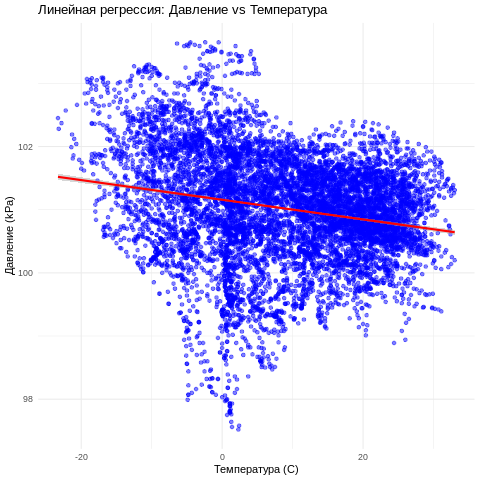

In [36]:
%%R
if (!require(caret)) {
    install.packages("caret")
    library(caret)
}
library(caret)
library(ggplot2)

X <- MData1['Temp_C']
y <- MData1['Press_kPa']

train_index <- createDataPartition(y$Press_kPa, p = 0.8, list = FALSE)
X_train <- X[train_index, , drop = FALSE]
X_test <- X[-train_index, , drop = FALSE]
y_train <- y[train_index, , drop = FALSE]
y_test <- y[-train_index, , drop = FALSE]

model_lr <- lm(Press_kPa ~ Temp_C, data = cbind(X_train, y_train))

y_pred <- predict(model_lr, newdata = X_test)

mse <- mean((y_test$Press_kPa - y_pred)^2)
print(paste("Величина ошибки (MSE):", mse))
print(paste("Стандартное отклонение ответов:", sd(y$Press_kPa)))

ggplot(data = MData1, aes(x = Temp_C, y = Press_kPa)) +
  geom_point(alpha = 0.5, color = 'blue') +
  geom_smooth(method = "lm", formula = y ~ x, color = 'red', linewidth = 1) +
  labs(x = 'Температура (C)',
       y = 'Давление (kPa)',
       title = 'Линейная регрессия: Давление vs Температура') +
  theme_minimal()

In [37]:
%%R
X <- data[, c('Temp_C', 'Rel.Hum_.', 'Wind.Speed_km.h')]
y <- data[, 'Press_kPa']

set.seed(123)
sample_size <- floor(0.8 * nrow(data))
train_indices <- sample(seq_len(nrow(data)), size = sample_size)

X_train <- as.matrix(X[train_indices, ])
X_test <- as.matrix(X[-train_indices, ])
y_train <- y[train_indices]
y_test <- y[-train_indices]

model_ridge <- glmnet(X_train, y_train, alpha = 0, lambda = 1)

y_pred <- predict(model_ridge, newx = X_test)

mse <- mean((y_test - y_pred)^2)
print(paste("Величина ошибки:", mse, "стандартное отклонение ответов:", sd(y)))

print("Коэффициенты:")
print(coef(model_ridge))

[1] "Величина ошибки: 0.572862861943207 стандартное отклонение ответов: 0.844004745948648"
[1] "Коэффициенты:"
4 x 1 sparse Matrix of class "dgCMatrix"
                           s0
(Intercept)     101.831544609
Temp_C           -0.009193097
Rel.Hum_.        -0.006448927
Wind.Speed_km.h  -0.016994478


In [38]:
%%R
library(caret)

X <- data[, c('Temp_C', 'Rel.Hum_.', 'Wind.Speed_km.h')]
y <- data[, 'Press_kPa']


train_index <- createDataPartition(y, p = 0.8, list = FALSE)
X_train <- X[train_index, ]
X_test <- X[-train_index, ]
y_train <- y[train_index]
y_test <- y[-train_index]

ctrl <- trainControl(
  method = "cv",
  number = 2,
  verboseIter = TRUE
)

model <- train(
  x = X_train,
  y = y_train,
  method = "lm",
  preProcess = c("center", "scale"),
  trControl = ctrl
)

print(paste("Лучший R2 на кросс-валидации:", model$results$Rsquared))

print("Полиномиальная регрессия с разными степенями:")
degrees <- 1:6
results <- data.frame(degree = degrees, rsquared = NA)

for (degree in degrees) {

  poly_features <- poly(as.matrix(X_train), degree = degree, raw = TRUE)
  poly_data <- data.frame(poly_features, Press_kPa = y_train)

  poly_model <- lm(Press_kPa ~ ., data = poly_data)

  poly_test <- poly(as.matrix(X_test), degree = degree, raw = TRUE)
  poly_test_data <- data.frame(poly_test)

  y_pred <- predict(poly_model, newdata = poly_test_data)
  rsq <- 1 - sum((y_test - y_pred)^2) / sum((y_test - mean(y_test))^2)
  results$rsquared[results$degree == degree] <- rsq

  print(paste("Степень", degree, ": R2 =", round(rsq, 4)))
}

best_degree <- results$degree[which.max(results$rsquared)]
print(paste("Лучшая степень полинома:", best_degree))
print(paste("Лучший R2:", max(results$rsquared)))

+ Fold1: intercept=TRUE 
- Fold1: intercept=TRUE 
+ Fold2: intercept=TRUE 
- Fold2: intercept=TRUE 
Aggregating results
Fitting final model on full training set
[1] "Лучший R2 на кросс-валидации: 0.307366001406256"
[1] "Полиномиальная регрессия с разными степенями:"
[1] "Степень 1 : R2 = 0.2955"
[1] "Степень 2 : R2 = 0.311"
[1] "Степень 3 : R2 = 0.3202"
[1] "Степень 4 : R2 = 0.3272"
[1] "Степень 5 : R2 = 0.3317"
[1] "Степень 6 : R2 = 0.3339"
[1] "Лучшая степень полинома: 6"
[1] "Лучший R2: 0.33392213406751"


In [39]:
%%R
library(glmnet)

# Создаем полиномиальные признаки степени 4
poly_features <- poly(as.matrix(X_train), degree = 4, raw = TRUE)
X_train_poly <- poly_features
X_test_poly <- predict(poly_features, as.matrix(X_test))

model_ridge <- glmnet(X_train_poly, y_train, alpha = 0, lambda = 1)

y_pred <- predict(model_ridge, newx = X_test_poly)

mse <- mean((y_test - y_pred)^2)
print(paste("Величина ошибки:", mse, "стандартное отклонение ответов:", sd(y)))

[1] "Величина ошибки: 0.492604841282022 стандартное отклонение ответов: 0.844004745948648"
